# Livrable 2 :

In [2]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2025-04-17 18:17:08.861210: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744906628.872985    1944 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744906628.876371    1944 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744906628.885456    1944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744906628.885476    1944 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744906628.885477    1944 computation_placer.cc:177] computation placer alr

2.19.0


## Généation du dataset de photos

In [3]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="/mnt/c/Users/louag/Documents/CESI/Data_science/datasets/Photo")


Photo Dataset size: 9993


I0000 00:00:1744906634.480567    1944 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Bruitage du dataset

In [4]:
noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)
noisy_test_ds = data_loader.add_noise_to_dataset(test_ds)

In [5]:
from src.utils import show_batch_images

show_batch_images(noisy_train_ds)

ImportError: cannot import name 'show_batch_images' from 'src.utils' (/home/endium/Data_science/Leyenda/src/utils.py)

In [6]:
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from keras.models import Model

encoder_inputs = Input(shape=(256, 256, 3))  # Image RGB 256x256

# Conv Block 1
x = Conv2D(32, (3, 3), strides=2, padding='same')(encoder_inputs)  # (128, 128, 32)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Conv Block 2
x = Conv2D(64, (3, 3), strides=2, padding='same')(x)  # (64, 64, 64)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Conv Block 3
x = Conv2D(128, (3, 3), strides=2, padding='same')(x)  # (32, 32, 128)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Conv Block 4
x = Conv2D(256, (3, 3), strides=2, padding='same')(x)  # (16, 16, 256)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Conv Block 5
x = Conv2D(256, (3, 3), strides=2, padding='same')(x)  # (8, 8, 256)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

encoder_output = x  # Pas de flatten, on garde (8, 8, 256)

encoder = Model(encoder_inputs, encoder_output, name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,440 (3.74 MB)

 Trainable params: 979,968 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [7]:
from keras.layers import Input, Conv2DTranspose, BatchNormalization, LeakyReLU, Conv2D
from keras.models import Model

# --- Decoder simplifié ---
decoder_inputs = Input(shape=(8, 8, 256))  # Sortie directe de l'encodeur

# DeConv1
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(decoder_inputs)  # (16, 16, 128)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# DeConv2
x = Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same')(x)  # (32, 32, 128)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# DeConv3
x = Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same')(x)  # (64, 64, 64)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# DeConv4
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(x)  # (128, 128, 32)
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# DeConv5 - reconstruction finale
x = Conv2DTranspose(32, (3, 3), strides=(2, 2), padding='same')(x)  # (256, 256, 32)
decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # Sortie finale RGB

# Modèle decoder
decoder = Model(decoder_inputs, decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,403 (2.08 MB)

 Trainable params: 545,699 (2.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [8]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 256, 256, 32)   │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 546,403 (2.08 MB)

 Trainable params: 545,699 (2.08 MB)

 Non-trainable params: 704 (2.75 KB)

In [9]:
# -- Metrics Custom --
def ssim_metric(y_true, y_pred):
    # SSIM attend des valeurs entre [0, 1], donc il est important de s'assurer que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    
    # Calcul du SSIM sur les images RGB
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées

def psnr_metric(y_true, y_pred):
    # PSNR attend des valeurs entre [0, 1], donc on s'assure que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Normalisation entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Normalisation entre [0, 1]
    
    # Calcul du PSNR sur les images RGB
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées


In [10]:
from tensorflow.keras.models import Model

# On récupère la sortie de l'encodeur (le "latent space")
latent_space = encoder(encoder_inputs)

# On passe cette sortie directement dans le décodeur
outputs = decoder(latent_space)

# Maintenant, on crée l'autoencodeur avec l'encodeur et le décodeur
autoencoder = Model(encoder_inputs, outputs, name="autoencoder")

# Compilation de l'autoencodeur
autoencoder.compile(optimizer="adam", loss="mae", metrics=["mae", ssim_metric, psnr_metric])

# Résumé du modèle
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 8, 8, 256)      │       981,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 256, 256, 3)    │       546,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,527,843 (5.83 MB)

 Trainable params: 1,525,667 (5.82 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [11]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [12]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [13]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=100,
                    batch_size= 64,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/100


I0000 00:00:1744906676.024880    2197 service.cc:152] XLA service 0x7fc6b4128fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744906676.024951    2197 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-04-17 18:17:56.609312: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-17 18:17:57.589634: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-17 18:17:57.590524: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-17 18:17:57.591222: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-17 18:17:57.591661: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/A

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1231 - mae: 0.1231 - psnr_metric: 16.2915 - ssim_metric: 0.3232

2025-04-17 18:18:24.899727: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-17 18:18:24.899952: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-17 18:18:24.900124: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-17 18:18:24.900228: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-04-17 18:18:24.902438: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert/Assert
2025-04-17 18:18:24.902592: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert_1/Assert
2025-04-17 18:18:28.628025: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=1,k5=2,k14=5} for conv %cudnn-conv.26 = (f32[27,3,246,246]{3,2,1,0}, u8[0]{0}) custom-call(f32[27,3,256,256]{3,2,1,0} %bi

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1230 - mae: 0.1230 - psnr_metric: 16.2984 - ssim_metric: 0.3235

2025-04-17 18:18:37.700814: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-17 18:18:37.702772: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-17 18:18:37.704918: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-17 18:18:37.705847: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-04-17 18:18:37.744837: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert/Assert
2025-04-17 18:18:37.746636: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert_1/Assert
2025-04-17 18:18:41.512719: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-17 18:18:41.512901: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSI

200/200 ━━━━━━━━━━━━━━━━━━━━ 54s 168ms/step - loss: 0.1228 - mae: 0.1228 - psnr_metric: 16.3052 - ssim_metric: 0.3238 - val_loss: 0.1779 - val_mae: 0.1779 - val_psnr_metric: 13.5995 - val_ssim_metric: 0.3703
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - loss: 0.0803 - mae: 0.0803 - psnr_metric: 19.1868 - ssim_metric: 0.4516 - val_loss: 0.1088 - val_mae: 0.1088 - val_psnr_metric: 17.0323 - val_ssim_metric: 0.4662
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0759 - mae: 0.0759 - psnr_metric: 19.6508 - ssim_metric: 0.4779 - val_loss: 0.1038 - val_mae: 0.1038 - val_psnr_metric: 17.2874 - val_ssim_metric: 0.4771
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - loss: 0.0741 - mae: 0.0741 - psnr_metric: 19.8449 - ssim_metric: 0.4886 - val_loss: 0.0955 - val_mae: 0.0955 - val_psnr_metric: 17.9649 - val_ssim_metric: 0.4859
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - loss: 0.0727 - mae: 0.0727 - psnr_metric: 20.0081 - ssim_metric: 0.4976 - val_

In [14]:
import datetime

# Récupérer la date et l'heure actuelle
now = datetime.datetime.now()
timestamp = now.strftime("%d%m%Y_%H%M")  # Format : jour mois année _ heure minute

# Construire le chemin de sauvegarde
save_path = f"./../models/autoencoder_base_mae_{timestamp}.weights.h5"

# Sauvegarder
autoencoder.save_weights(save_path)


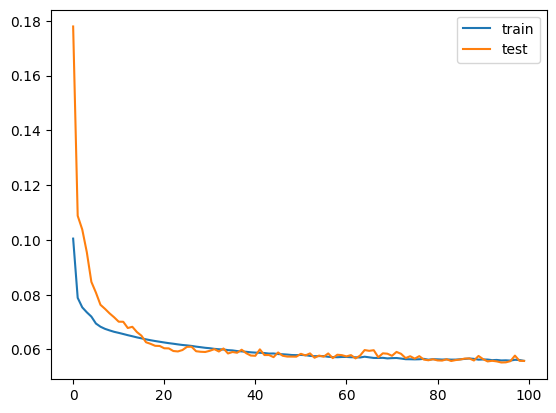

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


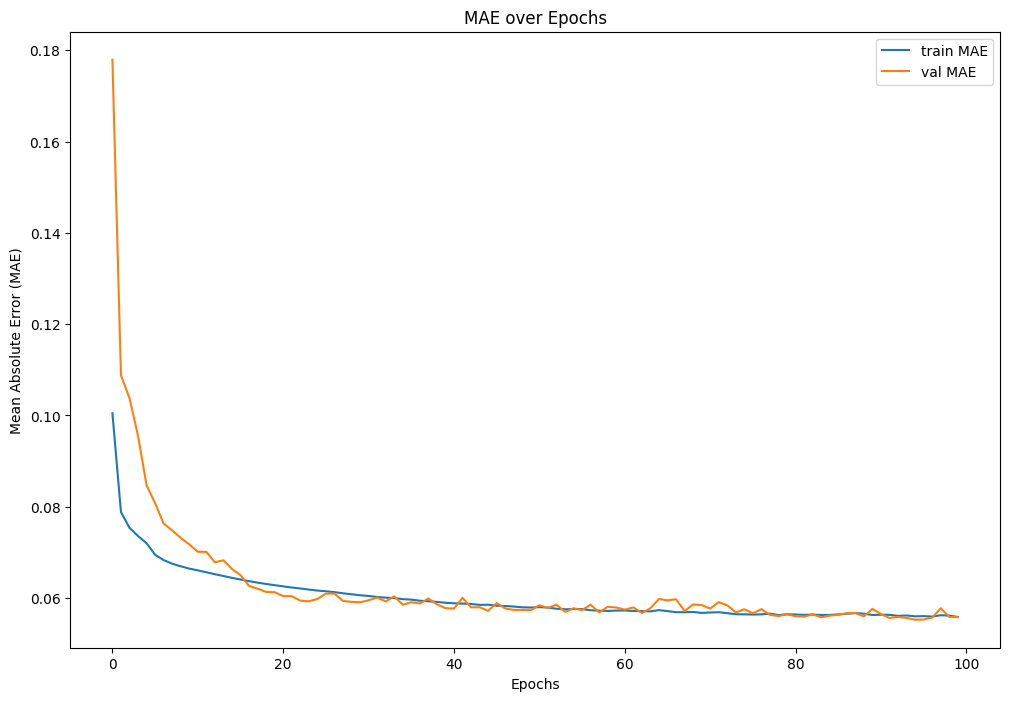

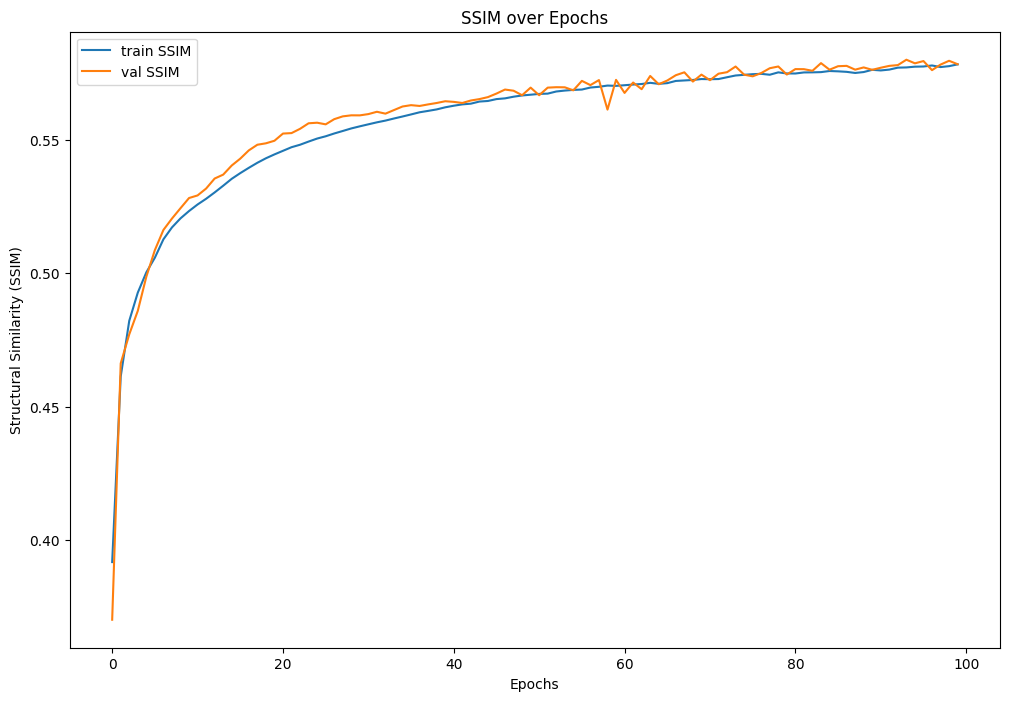

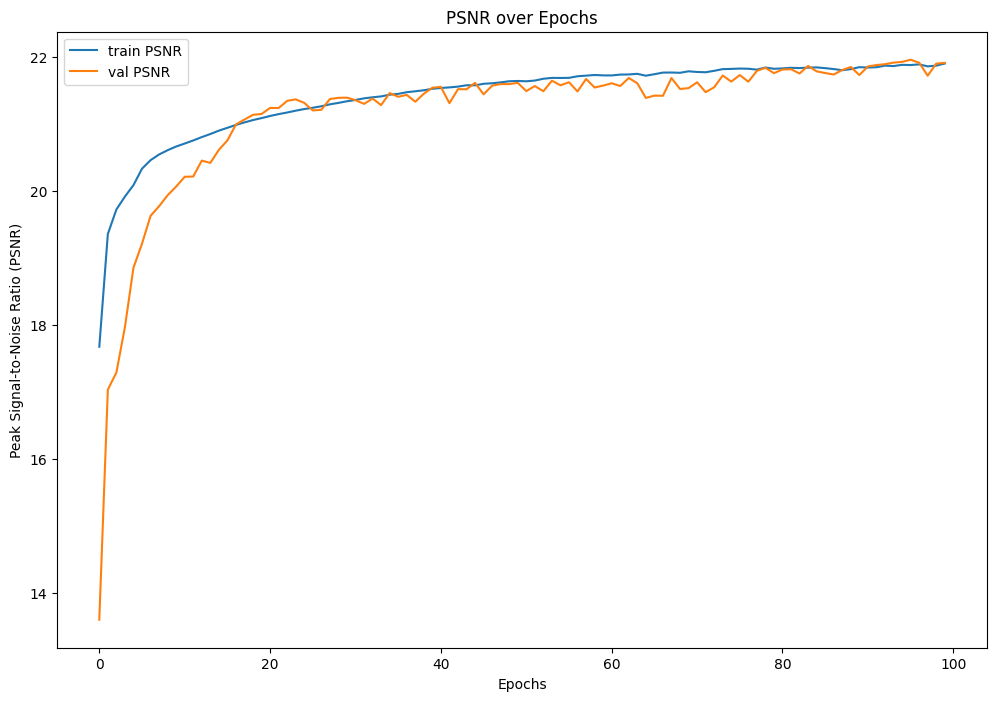

In [16]:
import matplotlib.pyplot as plt

# Tracer l'évolution de MAE
plt.figure(figsize=(12, 8))
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de SSIM
plt.figure(figsize=(12, 8))
plt.plot(history.history['ssim_metric'], label='train SSIM')
plt.plot(history.history['val_ssim_metric'], label='val SSIM')
plt.xlabel('Epochs')
plt.ylabel('Structural Similarity (SSIM)')
plt.title('SSIM over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de PSNR
plt.figure(figsize=(12, 8))
plt.plot(history.history['psnr_metric'], label='train PSNR')
plt.plot(history.history['val_psnr_metric'], label='val PSNR')
plt.xlabel('Epochs')
plt.ylabel('Peak Signal-to-Noise Ratio (PSNR)')
plt.title('PSNR over Epochs')
plt.legend()
plt.show()


# Evaluation de la reconstitutation

In [17]:
import cv2

def variance_of_laplacian_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

def tenengrad_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.mean(magnitude)


In [ ]:
import matplotlib.pyplot as plt


# Fonction SSIM
def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# Fonction PSNR
def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

# Fonction MAE
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def show_original_vs_decoded_with_sharpness(noisy_dataset, clean_dataset, model, n=10):
    noisy_images, _ = next(iter(noisy_dataset))
    clean_images, _ = next(iter(clean_dataset))

    decoded_images = model.predict(noisy_images)

    # Pour stocker toutes les métriques
    lap_sharpness_list = []
    ten_sharpness_list = []
    mae_list = []
    ssim_list = []
    psnr_list = []

    plt.figure(figsize=(18, 12))  # agrandi pour laisser encore plus de place
    for i in range(n):
        noisy = noisy_images[i].numpy()
        original = clean_images[i].numpy()
        decoded = decoded_images[i]

        # Calcul des métriques
        sharp_orig_lap = variance_of_laplacian_rgb(original)
        sharp_dec_lap = variance_of_laplacian_rgb(decoded)

        sharp_orig_ten = tenengrad_rgb(original)
        sharp_dec_ten = tenengrad_rgb(decoded)

        ssim_val = ssim_metric(original, decoded).numpy()
        psnr_val = psnr_metric(original, decoded).numpy()
        mae_val = mae_metric(original, decoded).numpy()

        # Score en % de netteté
        sharpness_percent_lap = (sharp_dec_lap / sharp_orig_lap) * 100 if sharp_orig_lap != 0 else 0
        sharpness_percent_ten = (sharp_dec_ten / sharp_orig_ten) * 100 if sharp_orig_ten != 0 else 0

        # Stockage
        lap_sharpness_list.append(sharpness_percent_lap)
        ten_sharpness_list.append(sharpness_percent_ten)
        mae_list.append(mae_val)
        ssim_list.append(ssim_val)
        psnr_list.append(psnr_val)

        # --- Affichage images ---

        # Image bruitée (entrée)
        ax = plt.subplot(5, n, i + 1)
        plt.imshow(noisy)
        plt.title("Bruitée")
        plt.axis("off")

        # Image originale
        ax = plt.subplot(5, n, n + i + 1)
        plt.imshow(original)
        plt.title(f"Originale\nLap: {sharp_orig_lap:.1f} | Ten: {sharp_orig_ten:.1f}")
        plt.axis("off")

        # Image reconstruite
        ax = plt.subplot(5, n, 2 * n + i + 1)
        plt.imshow(decoded)
        plt.title(
            f"Reconstruite\n"
            f"Lap: {sharp_dec_lap:.1f} ({sharpness_percent_lap:.1f}%)\n"
            f"Ten: {sharp_dec_ten:.1f} ({sharpness_percent_ten:.1f}%)\n"
            f"SSIM: {ssim_val:.3f} | PSNR: {psnr_val:.1f}\n"
            f"MAE: {mae_val:.4f}"
        )
        plt.axis("off")

    # Moyennes globales
    avg_lap = sum(lap_sharpness_list) / len(lap_sharpness_list)
    avg_ten = sum(ten_sharpness_list) / len(ten_sharpness_list)
    avg_mae = sum(mae_list) / len(mae_list)
    avg_ssim = sum(ssim_list) / len(ssim_list)
    avg_psnr = sum(psnr_list) / len(psnr_list)

    # Ajout d'un sous-plot pour afficher les moyennes
    ax = plt.subplot(5, 1, 5)
    plt.axis('off')
    plt.text(
        0.5, 0.5,
        (
            f"**Moyennes Globales**\n\n"
            f"Netteté Laplacian: {avg_lap:.2f}% | Tenengrad: {avg_ten:.2f}%\n"
            f"MAE: {avg_mae:.4f} | SSIM: {avg_ssim:.3f} | PSNR: {avg_psnr:.1f} dB"
        ),
        fontsize=16, ha='center', va='center', fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step


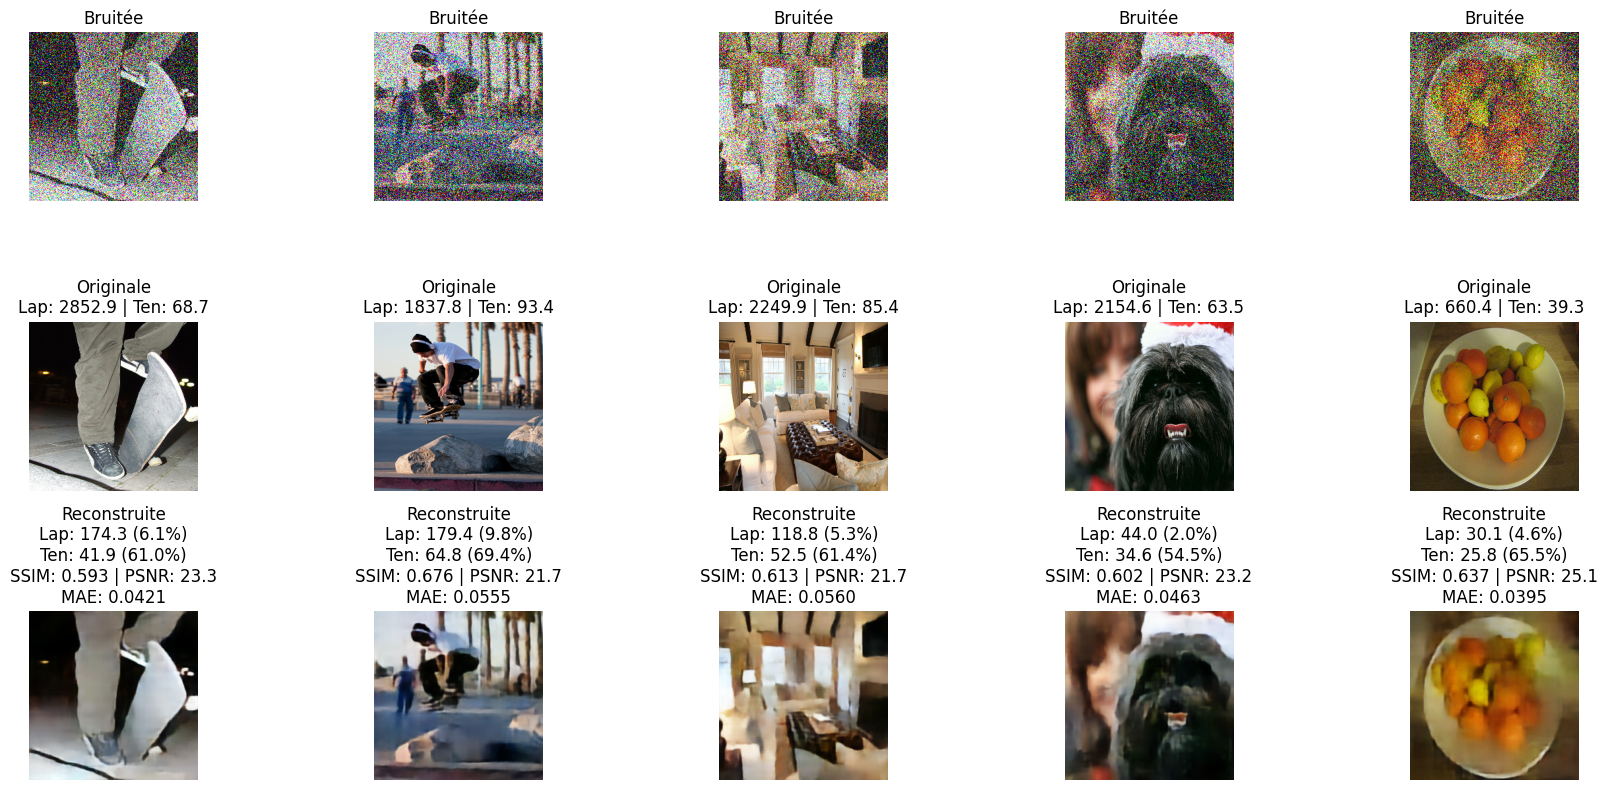

In [19]:
show_original_vs_decoded_with_sharpness(noisy_test_ds, test_ds, autoencoder, n=5)